<a href="https://colab.research.google.com/github/vivaanjain-1/Medlytics_2026/blob/main/DecisionTree_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Worksheet

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names=names)

X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

X_train, X_test, y_train, y_test = train_test_split(
    data[X_cols], data[y_col], test_size=0.2, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0)

print(X_train.shape, X_val.shape, X_test.shape)

(491, 8) (123, 8) (154, 8)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [6]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=20, min_samples_leaf=1, random_state=0)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20, random_state=0)

Print accuracy of training and validation data.

In [7]:
## YOUR CODE HERE
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Training Accuracy: 1.0
Validation Accuracy: 0.6991869918699187


Make a model with a low max-depth and higher minimum sample leafs.

In [8]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=0)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=0)

Print accuracy of training and validation data.

In [9]:
## YOUR CODE HERE
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Training Accuracy: 0.7841140529531568
Validation Accuracy: 0.7235772357723578


Explain the accuracy results below.


Same pattern as the SVM exercise.
High max depth + low min_samples_leaf lets the tree grow deep enough to perfectly memorize the training data (accuracy 1.0), but it doesn't generalize well (validation accuracy 0.699). It basically built a rule for every single training example instead of learning the real pattern.
Low max depth + higher min_samples_leaf keeps the tree simpler. Training accuracy is lower (0.784), but validation accuracy is better (0.724). It's a model that generalizes to new patients instead of memorizing old ones.So the low max depth model is the better choice here, since validation performance is what actually tells you how the model will do on new data.

## Metrics

Plot the ROC curve and print the AUC of the second model.

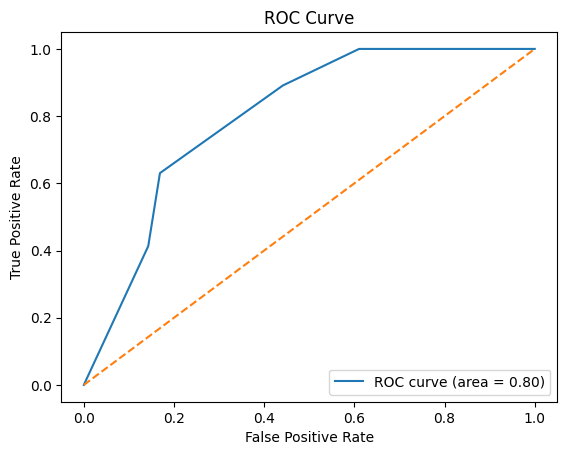

AUC: 0.7998306041784302


In [10]:
## YOUR CODE HERE
y_val_prob = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)
roc_auc = metrics.auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)

Use graphviz to visualize your 2nd tree.

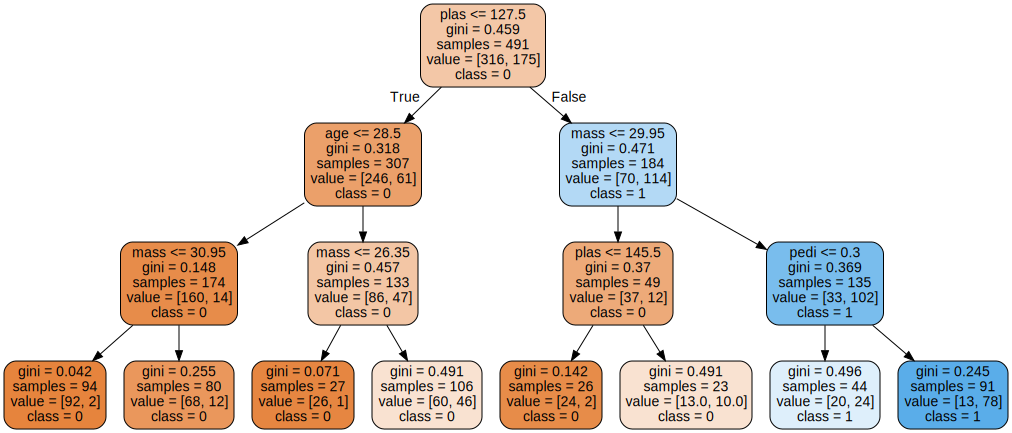

In [11]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(
    model, out_file=None,
    feature_names=X_cols,
    class_names=['0', '1'],
    filled=True, rounded=True
)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

**Question 1: What do you think X[n] represents in the nodes from the graph?**

X[n] just means the nth feature in the dataset, starting from 0. So X[0] is preg, X[1] is plas, and so on. In our tree we used feature_names, so it shows the actual column names instead of X[n], but it means the same thing.

**Question 2: What is the root feature? Does it make sense as the root feature?**

Root feature: plas (plasma glucose concentration), split at plas <= 127.5.

Does it make sense? Yes. Plasma glucose is the most direct medical indicator of diabetes out of all the features in this dataset. High blood sugar is literally the defining symptom of the disease, unlike more indirect factors like age or number of pregnancies. It makes sense that the tree picked it as the very first split, since decision trees choose the feature that best separates the classes at each step, and glucose is naturally the most predictive one available here.

**Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?**

With max_depth=500 and min_samples_leaf=1, the tree is basically allowed to grow without any real limit. It'll keep splitting until nodes are pure or have just 1 sample in them.

Training accuracy: Would go up to (or very close to) 1.0, since the tree can keep splitting until it perfectly separates every training example, even memorizing single outliers.

Test accuracy: Would likely go down compared to a shallower tree. The model would be fitting noise and quirks specific to the training data rather than the real underlying pattern, so it won't generalize well to new patients. This is the same overfitting effect we saw earlier with high gamma in the SVM and high max_depth in the earlier tree.

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [12]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=500, min_samples_leaf=1, random_state=0)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Training Accuracy: 1.0
Validation Accuracy: 0.6991869918699187


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [13]:
## YOUR CODE HERE
model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

Print accuracy of training and validation data.

In [14]:
## YOUR CODE HERE
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Training Accuracy: 1.0
Validation Accuracy: 0.7560975609756098


How did the accuracy compare to the decision tree's accuracy?

The random forest got validation accuracy of 0.756, which is better than the overfit decision tree(0.699 with high max_depth) and also better than the simpler single tree(0.724 with low max_depth). Even though training accuracy is still a perfect 1.0, the random forest generalizes much better than a single deep tree did. This is because a random forest builds many different trees on random subsets of data and features, then averages their votes, which cancels out the noise that any one tree might overfit to.

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [15]:
## YOUR CODE HERE
importances = model.feature_importances_

top3_idx = importances.argsort()[::-1][:3]

for i in top3_idx:
    print(X_cols[i], ":", importances[i])

plas : 0.2279111653180294
mass : 0.18112890427196723
age : 0.1475259250397474


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

n_estimators=1: Validation Accuracy = 0.6016
n_estimators=6: Validation Accuracy = 0.6911
n_estimators=11: Validation Accuracy = 0.7154
n_estimators=16: Validation Accuracy = 0.7724
n_estimators=21: Validation Accuracy = 0.7236
n_estimators=26: Validation Accuracy = 0.7236
n_estimators=31: Validation Accuracy = 0.7154
n_estimators=36: Validation Accuracy = 0.7236
n_estimators=41: Validation Accuracy = 0.7398
n_estimators=46: Validation Accuracy = 0.7317
n_estimators=51: Validation Accuracy = 0.7480
n_estimators=56: Validation Accuracy = 0.7317
n_estimators=61: Validation Accuracy = 0.7398
n_estimators=66: Validation Accuracy = 0.7480
n_estimators=71: Validation Accuracy = 0.7561
n_estimators=76: Validation Accuracy = 0.7480
n_estimators=81: Validation Accuracy = 0.7398
n_estimators=86: Validation Accuracy = 0.7398
n_estimators=91: Validation Accuracy = 0.7398
n_estimators=96: Validation Accuracy = 0.7561


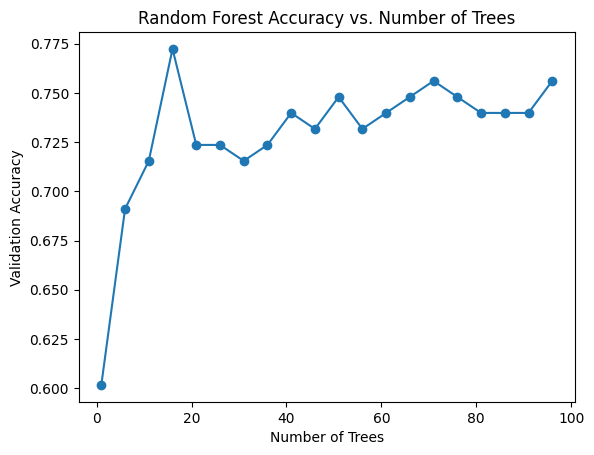

In [16]:
## YOUR CODE HERE
n_trees_list = range(1, 101, 5)
accuracies = []

for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=0)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_val, rf.predict(X_val))
    accuracies.append(acc)
    print(f"n_estimators={n}: Validation Accuracy = {acc:.4f}")

plt.plot(n_trees_list, accuracies, marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Validation Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

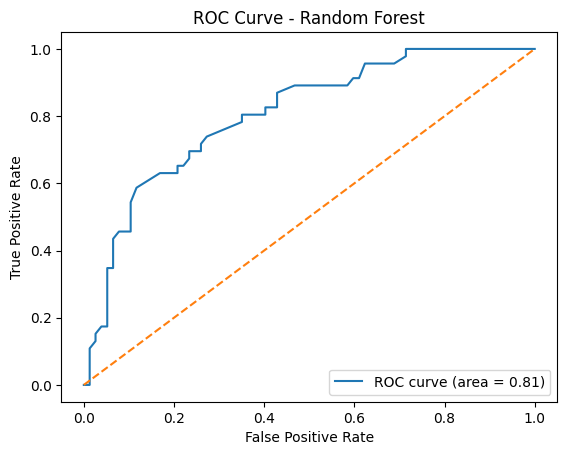

AUC: 0.8059006211180124


In [17]:
## YOUR CODE HERE
y_val_prob = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)
roc_auc = metrics.auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)